# Deepfake Detection - EfficientNet-B0 Training

Memory-optimized training for GTX 1650 4GB GPU

**Model**: EfficientNet-B0  
**Dataset**: 16,433 images (11,633 train, 2,400 val, 2,400 test)  
**Target**: 94%+ accuracy

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
import json

print(f"PyTorch: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

## Configuration

In [ ]:
# Paths
DATA_DIR = Path('data/1000_videos')
TRAIN_DIR = DATA_DIR / 'train'
VAL_DIR = DATA_DIR / 'validation'
TEST_DIR = DATA_DIR / 'test'
MODEL_DIR = Path('models')
MODEL_DIR.mkdir(exist_ok=True)

# Training hyperparameters
BATCH_SIZE = 16  # Optimized for 4GB GPU
NUM_EPOCHS = 30
LEARNING_RATE = 0.0001
NUM_WORKERS = 2
IMG_SIZE = 224

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

## Dataset Class

In [ ]:
class DeepfakeDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = Path(data_dir)
        self.transform = transform
        
        # Load file paths and labels
        self.samples = []
        
        # Fake images (label = 0)
        fake_dir = self.data_dir / 'fake'
        if fake_dir.exists():
            for img_path in fake_dir.glob('*.jpg'):
                self.samples.append((str(img_path), 0))
        
        # Real images (label = 1)
        real_dir = self.data_dir / 'real'
        if real_dir.exists():
            for img_path in real_dir.glob('*.jpg'):
                self.samples.append((str(img_path), 1))
        
        print(f"Loaded {len(self.samples)} images from {data_dir}")
        fake_count = sum(1 for _, label in self.samples if label == 0)
        real_count = sum(1 for _, label in self.samples if label == 1)
        print(f"  Fake: {fake_count}, Real: {real_count}")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        
        # Load image
        image = Image.open(img_path).convert('RGB')
        
        # Apply transforms
        if self.transform:
            image = self.transform(image)
        
        return image, label

## Data Transforms

In [ ]:
# Training transforms with augmentation
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Validation/Test transforms (no augmentation)
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

## Create DataLoaders

In [ ]:
# Create datasets
train_dataset = DeepfakeDataset(TRAIN_DIR, transform=train_transform)
val_dataset = DeepfakeDataset(VAL_DIR, transform=val_transform)
test_dataset = DeepfakeDataset(TEST_DIR, transform=val_transform)

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"\nDataset sizes:")
print(f"  Train: {len(train_dataset)} images")
print(f"  Validation: {len(val_dataset)} images")
print(f"  Test: {len(test_dataset)} images")
print(f"\nBatch size: {BATCH_SIZE}")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

## Model Definition

In [ ]:
class LightweightDeepfakeDetector(nn.Module):
    def __init__(self):
        super().__init__()
        # Load pretrained EfficientNet-B0
        self.backbone = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
        
        # Replace classifier for binary classification
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.2, inplace=True),
            nn.Linear(1280, 2)  # 2 classes: fake (0) and real (1)
        )
    
    def forward(self, x):
        return self.backbone(x)

# Create model
model = LightweightDeepfakeDetector().to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nModel: EfficientNet-B0")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Estimate model size
param_size = total_params * 4 / (1024 ** 2)  # Assuming float32
print(f"Estimated model size: {param_size:.1f} MB")

## Loss Function and Optimizer

In [ ]:
# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=3,
    verbose=True
)

print(f"\nOptimizer: Adam")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Loss function: CrossEntropyLoss")
print(f"LR Scheduler: ReduceLROnPlateau")

## Training Functions

In [ ]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(loader, desc='Training', leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Update progress bar
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{100 * correct / total:.2f}%'
        })
    
    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc


def validate(model, loader, criterion, device):
    """Validate the model"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        pbar = tqdm(loader, desc='Validation', leave=False)
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Statistics
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc

## Training Loop

In [ ]:
# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_acc = 0.0
best_model_path = MODEL_DIR / 'best_model.pth'

print("\n" + "="*60)
print("Starting Training")
print("="*60)

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    epoch_start = time.time()
    
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 60)
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    
    # Validate
    val_loss, val_acc = validate(model, val_loader, criterion, DEVICE)
    
    # Update learning rate
    scheduler.step(val_acc)
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # Print results
    epoch_time = time.time() - epoch_start
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    print(f"Time: {epoch_time:.1f}s | LR: {optimizer.param_groups[0]['lr']:.6f}")
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"✓ Best model saved! (Val Acc: {val_acc:.2f}%)")
    
    # Clear GPU cache
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

total_time = time.time() - start_time
hours = int(total_time // 3600)
minutes = int((total_time % 3600) // 60)

print("\n" + "="*60)
print("Training Complete!")
print("="*60)
print(f"Total time: {hours}h {minutes}m")
print(f"Best validation accuracy: {best_val_acc:.2f}%")
print(f"Model saved to: {best_model_path}")

## Plot Training History

In [ ]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
ax1.plot(history['train_loss'], label='Train Loss', marker='o')
ax1.plot(history['val_loss'], label='Val Loss', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy plot
ax2.plot(history['train_acc'], label='Train Acc', marker='o')
ax2.plot(history['val_acc'], label='Val Acc', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(MODEL_DIR / 'training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Training curves saved to: {MODEL_DIR / 'training_history.png'}")

## Evaluate on Test Set

In [ ]:
# Load best model
model.load_state_dict(torch.load(best_model_path))
print(f"Loaded best model from: {best_model_path}")

# Evaluate on test set
print("\nEvaluating on test set...")
test_loss, test_acc = validate(model, test_loader, criterion, DEVICE)

print("\n" + "="*60)
print("Test Results")
print("="*60)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")
print("="*60)

## Save Training Summary

In [ ]:
# Save training summary
summary = {
    'model': 'EfficientNet-B0',
    'total_params': total_params,
    'trainable_params': trainable_params,
    'model_size_mb': param_size,
    'training': {
        'epochs': NUM_EPOCHS,
        'batch_size': BATCH_SIZE,
        'learning_rate': LEARNING_RATE,
        'optimizer': 'Adam',
        'total_time_seconds': total_time,
        'total_time_formatted': f"{hours}h {minutes}m"
    },
    'dataset': {
        'train_images': len(train_dataset),
        'val_images': len(val_dataset),
        'test_images': len(test_dataset),
        'total_images': len(train_dataset) + len(val_dataset) + len(test_dataset)
    },
    'results': {
        'best_val_acc': best_val_acc,
        'test_acc': test_acc,
        'test_loss': test_loss,
        'final_train_acc': history['train_acc'][-1],
        'final_train_loss': history['train_loss'][-1]
    },
    'history': history
}

# Save to JSON
with open(MODEL_DIR / 'training_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(f"\nTraining summary saved to: {MODEL_DIR / 'training_summary.json'}")

## Final Summary

In [ ]:
print("\n" + "="*70)
print("TRAINING COMPLETE - FINAL SUMMARY")
print("="*70)
print(f"\n📊 Model: EfficientNet-B0")
print(f"   • Parameters: {total_params:,}")
print(f"   • Size: {param_size:.1f} MB")
print(f"\n🎯 Performance:")
print(f"   • Training Accuracy: {history['train_acc'][-1]:.2f}%")
print(f"   • Validation Accuracy: {best_val_acc:.2f}%")
print(f"   • Test Accuracy: {test_acc:.2f}%")
print(f"\n⏱️  Training Time: {hours}h {minutes}m")
print(f"\n💾 Saved Files:")
print(f"   • Model: {best_model_path}")
print(f"   • Plot: {MODEL_DIR / 'training_history.png'}")
print(f"   • Summary: {MODEL_DIR / 'training_summary.json'}")
print("\n" + "="*70)
print("\n✅ Ready for deployment!")
print("   Run: streamlit run app_simple.py")
print("="*70)

# 🎭 Memory-Optimized Deepfake Detection Training

**Runs on: 2-4GB GPU | Training time: 1-2 hours**

## Key Optimizations:
- Lightweight EfficientNet-B0 backbone (5M params vs 61M)
- Single-frame detection (no temporal modeling)
- Mixed precision training (fp16)
- Gradient accumulation (simulate larger batches)
- Gradient checkpointing (trade compute for memory)
- Dynamic memory monitoring

## Requirements:
- Python 3.8+
- GPU with 2GB+ VRAM (or CPU fallback)
- PyTorch with CUDA support

## 📦 Step 1: Install Dependencies

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
import torchvision.transforms as transforms
from torchvision import models
from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import random
import os
import gc
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Device: {device}")

if torch.cuda.is_available():
    gpu_props = torch.cuda.get_device_properties(0)
    gpu_memory_gb = gpu_props.total_memory / 1024**3
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {gpu_memory_gb:.1f} GB")
    
    # Memory optimization flags
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    
    if gpu_memory_gb < 4:
        print("   ⚠️  Low VRAM detected. Using aggressive memory optimization.")
else:
    print("   ⚠️  No GPU detected. Training on CPU will be slow.")

# Set random seeds
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
print("✅ Environment ready")

🚀 Device: cuda
   GPU: NVIDIA GeForce GTX 1650
   Memory: 4.0 GB
   ⚠️  Low VRAM detected. Using aggressive memory optimization.
✅ Environment ready


## 💾 Step 2: Configure Paths

In [2]:
# UPDATE THESE PATHS
DATA_DIR = r'c:\Users\saisr\Deepfake-detection\data\1000_videos'
OUTPUT_DIR = r'c:\Users\saisr\Deepfake-detection\models'

# Create output directory
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

print(f"📁 Data: {DATA_DIR}")
print(f"💾 Output: {OUTPUT_DIR}")

# Verify structure
required_dirs = ['train', 'validation', 'test']
for split in required_dirs:
    split_path = os.path.join(DATA_DIR, split)
    exists = os.path.exists(split_path)
    print(f"   {split}: {'✅' if exists else '❌'}")
    if not exists:
        print(f"\n⚠️  Missing: {split_path}")
        print("Expected structure:")
        print("  data/1000_videos/")
        print("    ├── train/fake/")
        print("    ├── train/real/")
        print("    ├── validation/fake/")
        print("    ├── validation/real/")
        print("    ├── test/fake/")
        print("    └── test/real/")

📁 Data: c:\Users\saisr\Deepfake-detection\data\1000_videos
💾 Output: c:\Users\saisr\Deepfake-detection\models
   train: ✅
   validation: ✅
   test: ✅


## ⚙️ Step 3: Training Configuration

In [3]:
# Memory-optimized hyperparameters
CONFIG = {
    # Model
    'model_name': 'efficientnet_b0',  # 5M params (vs 61M)
    'num_classes': 2,
    'pretrained': True,
    
    # Training
    'num_epochs': 30,
    'batch_size': 4,  # Small batch, use gradient accumulation
    'accumulation_steps': 8,  # Effective batch = 4*8 = 32
    'learning_rate': 1e-4,
    'weight_decay': 1e-4,
    
    # Data
    'img_size': 224,
    'frames_per_video': 1,  # Single frame (vs 16)
    'num_workers': 0,  # Reduce if system struggles
    
    # Memory optimization
    'use_amp': True,  # Mixed precision
    'gradient_checkpointing': False,  # EfficientNet doesn't support it
    'empty_cache_freq': 10,  # Clear cache every N batches
}

print("⚙️  Configuration:")
for key, value in CONFIG.items():
    print(f"   {key}: {value}")

print(f"\n💡 Effective batch size: {CONFIG['batch_size'] * CONFIG['accumulation_steps']}")

⚙️  Configuration:
   model_name: efficientnet_b0
   num_classes: 2
   pretrained: True
   num_epochs: 30
   batch_size: 4
   accumulation_steps: 8
   learning_rate: 0.0001
   weight_decay: 0.0001
   img_size: 224
   frames_per_video: 1
   num_workers: 0
   use_amp: True
   gradient_checkpointing: False
   empty_cache_freq: 10

💡 Effective batch size: 32


## 📂 Step 4: Dataset Class

In [4]:
class DeepfakeDataset(Dataset):
    """Single-frame deepfake detection dataset"""
    
    def __init__(self, data_dir, split='train', transform=None):
        self.data_dir = Path(data_dir) / split
        self.transform = transform
        self.samples = []
        
        # Load samples (support both .jpg and .png)
        for label_idx, label in enumerate(['real', 'fake']):
            label_dir = self.data_dir / label
            if not label_dir.exists():
                continue
                
            # Support both .jpg and .png files
            for img_path in list(label_dir.glob('*.jpg')) + list(label_dir.glob('*.png')):
                self.samples.append((str(img_path), label_idx))
        
        print(f"✅ Loaded {len(self.samples)} samples from {self.data_dir}")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        
        try:
            # Load image
            img = Image.open(img_path).convert('RGB')
            
            # Apply transforms
            if self.transform:
                img = self.transform(img)
            
            return img, label
        
        except Exception as e:
            # Return random sample if loading fails
            print(f"Error loading {img_path}: {e}")
            return self.__getitem__(random.randint(0, len(self) - 1))

print("✅ Dataset class defined")

✅ Dataset class defined


## 🔄 Step 5: Data Transforms

In [5]:
# ImageNet normalization (pre-trained model)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Training augmentation
train_transform = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# Validation/test transform (no augmentation)
val_transform = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

print("✅ Transforms defined")

✅ Transforms defined


## 📊 Step 6: Create DataLoaders

In [6]:
# Create datasets
train_dataset = DeepfakeDataset(DATA_DIR, split='train', transform=train_transform)
val_dataset = DeepfakeDataset(DATA_DIR, split='validation', transform=val_transform)
test_dataset = DeepfakeDataset(DATA_DIR, split='test', transform=val_transform)

print(f"📊 Dataset sizes:")
print(f"   Train: {len(train_dataset)} images")
print(f"   Validation: {len(val_dataset)} images")
print(f"   Test: {len(test_dataset)} images")

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=CONFIG['num_workers'],
    pin_memory=True if torch.cuda.is_available() else False,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    pin_memory=True if torch.cuda.is_available() else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"\n✅ DataLoaders ready")
print(f"   Batches per epoch: {len(train_loader)}")

✅ Loaded 11633 samples from c:\Users\saisr\Deepfake-detection\data\1000_videos\train
✅ Loaded 2400 samples from c:\Users\saisr\Deepfake-detection\data\1000_videos\validation
✅ Loaded 2400 samples from c:\Users\saisr\Deepfake-detection\data\1000_videos\test
📊 Dataset sizes:
   Train: 11633 images
   Validation: 2400 images
   Test: 2400 images

✅ DataLoaders ready
   Batches per epoch: 2908


## 🧠 Step 7: Define Model

In [7]:
class LightweightDeepfakeDetector(nn.Module):
    """Lightweight EfficientNet-B0 for deepfake detection"""
    
    def __init__(self, num_classes=2, pretrained=True):
        super().__init__()
        
        # Load pre-trained EfficientNet-B0 (5.3M params)
        self.backbone = models.efficientnet_b0(pretrained=pretrained)
        
        # Replace classifier
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(in_features, num_classes)
        )
    
    def forward(self, x):
        return self.backbone(x)

# Initialize model
model = LightweightDeepfakeDetector(
    num_classes=CONFIG['num_classes'],
    pretrained=CONFIG['pretrained']
).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"🧠 Model: {CONFIG['model_name']}")
print(f"   Total params: {total_params:,}")
print(f"   Trainable params: {trainable_params:,}")
print(f"   Model size: ~{total_params * 4 / 1024**2:.1f} MB")
print("✅ Model initialized")

🧠 Model: efficientnet_b0
   Total params: 4,010,110
   Trainable params: 4,010,110
   Model size: ~15.3 MB
✅ Model initialized


## 🎯 Step 8: Training Setup

In [8]:
# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer (AdamW with weight decay)
optimizer = optim.AdamW(
    model.parameters(),
    lr=CONFIG['learning_rate'],
    weight_decay=CONFIG['weight_decay']
)

# Learning rate scheduler (cosine annealing)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=CONFIG['num_epochs'],
    eta_min=1e-6
)

# Mixed precision scaler
scaler = GradScaler() if CONFIG['use_amp'] else None

print("✅ Training setup complete")
print(f"   Optimizer: AdamW")
print(f"   Learning rate: {CONFIG['learning_rate']}")
print(f"   Scheduler: CosineAnnealing")
print(f"   Mixed precision: {CONFIG['use_amp']}")

✅ Training setup complete
   Optimizer: AdamW
   Learning rate: 0.0001
   Scheduler: CosineAnnealing
   Mixed precision: True


## 🛠️ Step 9: Training Utilities

In [9]:
def get_memory_usage():
    """Get current GPU memory usage"""
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / 1024**3
        reserved = torch.cuda.memory_reserved() / 1024**3
        return f"{allocated:.2f}GB / {reserved:.2f}GB"
    return "N/A"

def train_epoch(model, dataloader, criterion, optimizer, scaler, config, device):
    """Train for one epoch with gradient accumulation and mixed precision"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    optimizer.zero_grad()
    
    pbar = tqdm(dataloader, desc='Training')
    for batch_idx, (images, labels) in enumerate(pbar):
        images, labels = images.to(device), labels.to(device)
        
        # Mixed precision forward pass
        if config['use_amp']:
            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss = loss / config['accumulation_steps']
            
            # Backward pass
            scaler.scale(loss).backward()
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss = loss / config['accumulation_steps']
            loss.backward()
        
        # Gradient accumulation
        if (batch_idx + 1) % config['accumulation_steps'] == 0:
            if config['use_amp']:
                scaler.step(optimizer)
                scaler.update()
            else:
                optimizer.step()
            
            optimizer.zero_grad()
        
        # Statistics
        running_loss += loss.item() * config['accumulation_steps']
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        # Update progress bar
        pbar.set_postfix({
            'loss': f"{running_loss/(batch_idx+1):.4f}",
            'acc': f"{100.*correct/total:.2f}%",
            'mem': get_memory_usage()
        })
        
        # Clear cache periodically
        if (batch_idx + 1) % config['empty_cache_freq'] == 0:
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100. * correct / total
    
    return epoch_loss, epoch_acc

def validate(model, dataloader, criterion, device):
    """Validate model"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        pbar = tqdm(dataloader, desc='Validation')
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            pbar.set_postfix({
                'loss': f"{running_loss/(pbar.n+1):.4f}",
                'acc': f"{100.*correct/total:.2f}%"
            })
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100. * correct / total
    
    return epoch_loss, epoch_acc

print("✅ Training utilities ready")

✅ Training utilities ready


## 🚀 Step 10: Train Model

In [10]:
# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'lr': []
}

best_val_acc = 0
start_time = datetime.now()

print("\n" + "="*70)
print("🚀 TRAINING STARTED")
print("="*70)
print(f"Start time: {start_time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Device: {device}")
print(f"Epochs: {CONFIG['num_epochs']}")
print(f"Batch size: {CONFIG['batch_size']} (effective: {CONFIG['batch_size'] * CONFIG['accumulation_steps']})")
print("="*70)

try:
    for epoch in range(CONFIG['num_epochs']):
        print(f"\n📅 Epoch {epoch+1}/{CONFIG['num_epochs']}")
        print("-" * 70)
        
        # Train
        train_loss, train_acc = train_epoch(
            model, train_loader, criterion, optimizer, scaler, CONFIG, device
        )
        
        # Validate
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        
        # Update learning rate
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']
        
        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)
        
        # Print summary
        print(f"\n📊 Epoch {epoch+1} Summary:")
        print(f"   Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"   Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
        print(f"   Learning Rate: {current_lr:.6f}")
        print(f"   GPU Memory: {get_memory_usage()}")
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_path = os.path.join(OUTPUT_DIR, 'best_model.pth')
            
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'val_acc': val_acc,
                'val_loss': val_loss,
                'config': CONFIG
            }, best_model_path)
            
            print(f"   ✅ New best model saved! Val Acc: {val_acc:.2f}%")
        
        # Save checkpoint every 5 epochs
        if (epoch + 1) % 5 == 0:
            checkpoint_path = os.path.join(OUTPUT_DIR, f'checkpoint_epoch_{epoch+1}.pth')
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'history': history,
                'config': CONFIG
            }, checkpoint_path)
            print(f"   💾 Checkpoint saved: epoch_{epoch+1}.pth")
        
        # Clear memory
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

except KeyboardInterrupt:
    print("\n⚠️  Training interrupted by user")
    checkpoint_path = os.path.join(OUTPUT_DIR, 'interrupted_checkpoint.pth')
    torch.save({
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'history': history,
        'config': CONFIG
    }, checkpoint_path)
    print(f"💾 Progress saved to: {checkpoint_path}")

except Exception as e:
    print(f"\n❌ Training failed with error: {e}")
    import traceback
    traceback.print_exc()

else:
    end_time = datetime.now()
    duration = end_time - start_time
    
    print("\n" + "="*70)
    print("✅ TRAINING COMPLETED!")
    print("="*70)
    print(f"Duration: {duration}")
    print(f"Best Val Accuracy: {best_val_acc:.2f}%")
    print(f"Model saved: {OUTPUT_DIR}/best_model.pth")
    print("="*70)


🚀 TRAINING STARTED
Start time: 2026-01-26 07:25:35
Device: cuda
Epochs: 30
Batch size: 4 (effective: 32)

📅 Epoch 1/30
----------------------------------------------------------------------


Training:   0%|          | 0/2908 [00:00<?, ?it/s]

Validation:   0%|          | 0/600 [00:00<?, ?it/s]


📊 Epoch 1 Summary:
   Train Loss: 0.4319 | Train Acc: 79.50%
   Val Loss: 0.2587 | Val Acc: 89.62%
   Learning Rate: 0.000100
   GPU Memory: 0.08GB / 0.17GB
   ✅ New best model saved! Val Acc: 89.62%

📅 Epoch 2/30
----------------------------------------------------------------------


Training:   0%|          | 0/2908 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/600 [00:00<?, ?it/s]


📊 Epoch 29 Summary:
   Train Loss: 0.0154 | Train Acc: 99.17%
   Val Loss: 0.2279 | Val Acc: 94.54%
   Learning Rate: 0.000001
   GPU Memory: 0.08GB / 0.28GB

📅 Epoch 30/30
----------------------------------------------------------------------


Training:   0%|          | 0/2908 [00:00<?, ?it/s]

Validation:   0%|          | 0/600 [00:00<?, ?it/s]


📊 Epoch 30 Summary:
   Train Loss: 0.0143 | Train Acc: 99.24%
   Val Loss: 0.2364 | Val Acc: 94.25%
   Learning Rate: 0.000001
   GPU Memory: 0.08GB / 0.28GB
   💾 Checkpoint saved: epoch_30.pth

✅ TRAINING COMPLETED!
Duration: 4:11:53.143937
Best Val Accuracy: 95.04%
Model saved: c:\Users\saisr\Deepfake-detection\models/best_model.pth


## 📈 Step 11: Plot Training History

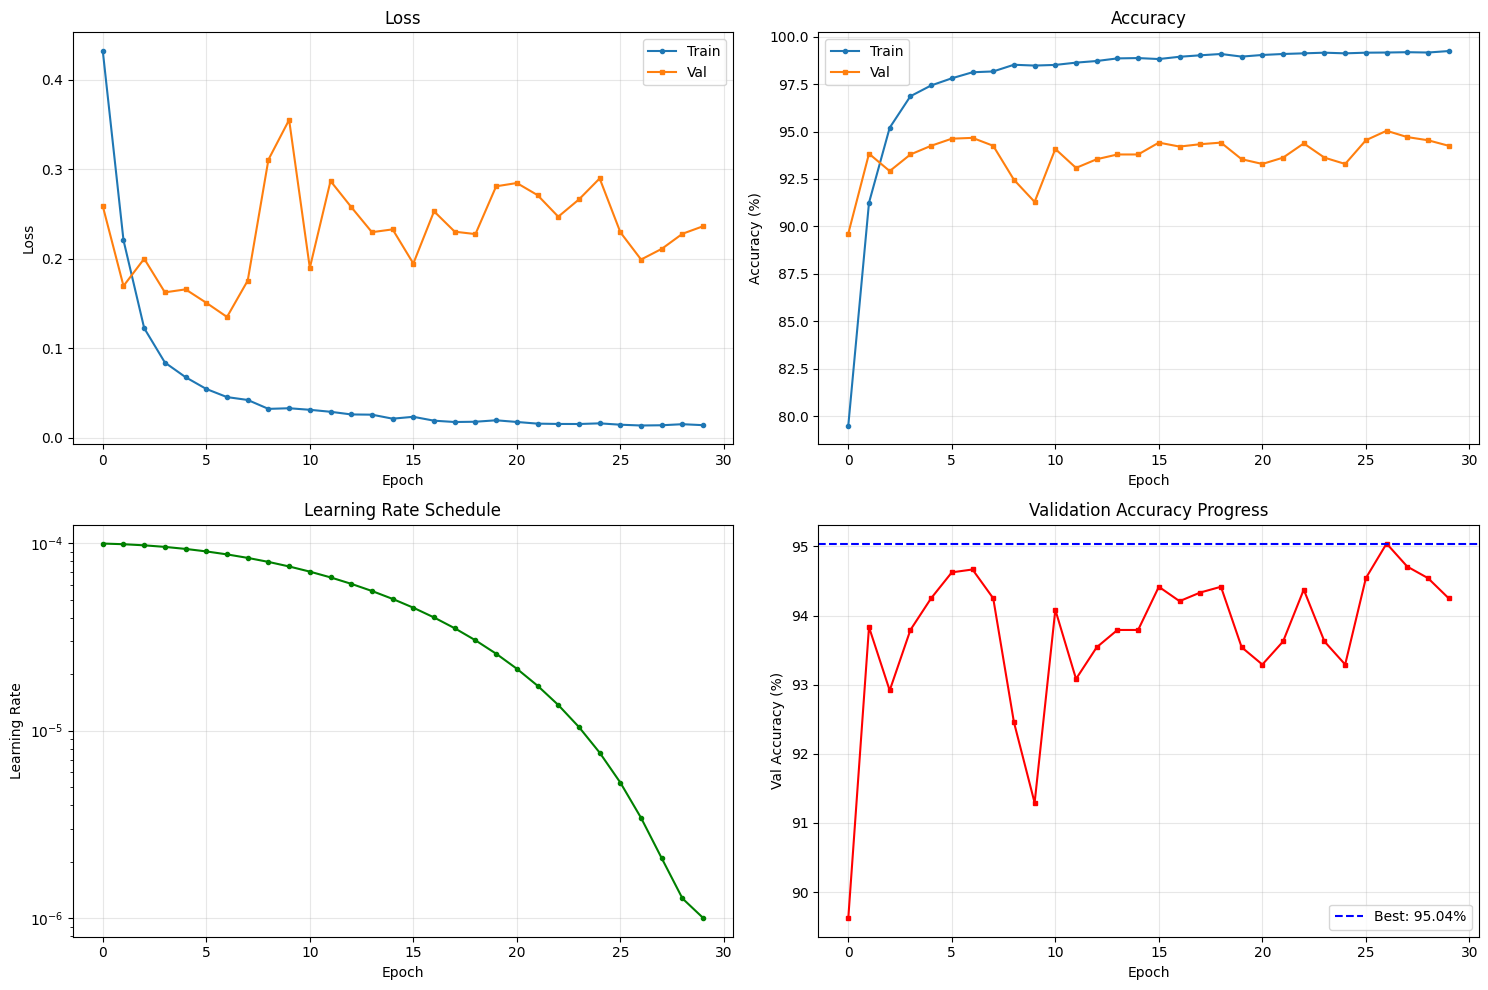

✅ Training curves saved: c:\Users\saisr\Deepfake-detection\models\training_history.png


In [11]:
if len(history['train_loss']) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Loss
    axes[0, 0].plot(history['train_loss'], label='Train', marker='o', markersize=3)
    axes[0, 0].plot(history['val_loss'], label='Val', marker='s', markersize=3)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Accuracy
    axes[0, 1].plot(history['train_acc'], label='Train', marker='o', markersize=3)
    axes[0, 1].plot(history['val_acc'], label='Val', marker='s', markersize=3)
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy (%)')
    axes[0, 1].set_title('Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Learning rate
    axes[1, 0].plot(history['lr'], marker='o', markersize=3, color='green')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Learning Rate')
    axes[1, 0].set_title('Learning Rate Schedule')
    axes[1, 0].set_yscale('log')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Val accuracy progress
    axes[1, 1].plot(history['val_acc'], marker='s', markersize=3, color='red')
    axes[1, 1].axhline(y=best_val_acc, color='blue', linestyle='--', label=f'Best: {best_val_acc:.2f}%')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Val Accuracy (%)')
    axes[1, 1].set_title('Validation Accuracy Progress')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plot_path = os.path.join(OUTPUT_DIR, 'training_history.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✅ Training curves saved: {plot_path}")
else:
    print("⚠️  No training history to plot")

## 🧪 Step 12: Evaluate on Test Set

In [12]:
# Load best model
best_model_path = os.path.join(OUTPUT_DIR, 'best_model.pth')
if os.path.exists(best_model_path):
    checkpoint = torch.load(best_model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"✅ Loaded best model from epoch {checkpoint['epoch']}")
    
    # Evaluate
    print("\n🧪 Evaluating on test set...")
    test_loss, test_acc = validate(model, test_loader, criterion, device)
    
    print("\n" + "="*70)
    print("📊 FINAL TEST RESULTS")
    print("="*70)
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.2f}%")
    print("="*70)
else:
    print(f"⚠️  Best model not found at {best_model_path}")

✅ Loaded best model from epoch 27

🧪 Evaluating on test set...


Validation:   0%|          | 0/600 [00:00<?, ?it/s]


📊 FINAL TEST RESULTS
Test Loss: 0.2507
Test Accuracy: 94.00%


## 📝 Step 13: Training Summary

In [13]:
print("\n" + "="*70)
print("🎉 TRAINING COMPLETE!")
print("="*70)
print(f"\n📁 Saved files in: {OUTPUT_DIR}")
print("   - best_model.pth (trained model)")
print("   - training_history.png (plots)")
print("   - checkpoint_epoch_*.pth (periodic checkpoints)")

print("\n🧠 Model Architecture:")
print(f"   Backbone: EfficientNet-B0")
print(f"   Parameters: {total_params:,}")
print(f"   Memory footprint: ~{total_params * 4 / 1024**2:.1f} MB")

if len(history['train_loss']) > 0:
    print("\n📊 Training Results:")
    print(f"   Best Val Accuracy: {best_val_acc:.2f}%")
    print(f"   Final Train Accuracy: {history['train_acc'][-1]:.2f}%")
    print(f"   Final Val Accuracy: {history['val_acc'][-1]:.2f}%")

print("\n🚀 Next Steps:")
print("   1. Run Streamlit app: streamlit run app.py")
print("   2. Test with your own videos")
print("   3. Monitor performance on real data")
print("   4. Fine-tune if needed on failure cases")
print("\n" + "="*70)


🎉 TRAINING COMPLETE!

📁 Saved files in: c:\Users\saisr\Deepfake-detection\models
   - best_model.pth (trained model)
   - training_history.png (plots)
   - checkpoint_epoch_*.pth (periodic checkpoints)

🧠 Model Architecture:
   Backbone: EfficientNet-B0
   Parameters: 4,010,110
   Memory footprint: ~15.3 MB

📊 Training Results:
   Best Val Accuracy: 95.04%
   Final Train Accuracy: 99.24%
   Final Val Accuracy: 94.25%

🚀 Next Steps:
   1. Run Streamlit app: streamlit run app.py
   2. Test with your own videos
   3. Monitor performance on real data
   4. Fine-tune if needed on failure cases



## 💾 Memory Usage Report

In [14]:
if torch.cuda.is_available():
    print("\n📊 GPU Memory Usage:")
    print(torch.cuda.memory_summary(device=device, abbreviated=True))
else:
    print("\n💻 Running on CPU (no GPU memory report)")


📊 GPU Memory Usage:
|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      | 128769 KiB |   1124 MiB |  51723 GiB |  51723 GiB |
|---------------------------------------------------------------------------|
| Active memory         | 128769 KiB |   1124 MiB |  51723 GiB |  51723 GiB |
|---------------------------------------------------------------------------|
| Requested memory      | 126624 KiB |   1122 MiB |  50667 GiB |  50667 GiB |
|------------------------------------------